# Long-Short (Dollar-Neutral) Momentum — two widths, monthly & weekly

Cross-sectional momentum traded **long-short**: each rebalance go **long the high-
momentum names** and **short the low-momentum names** by risk-adjusted 12-1 momentum,
each leg summing to ±1 → **net 0, gross 2×** before vol-targeting (scaled to a **20%
vol target**; gross leverage = 2 × multiplier). Two selection widths, both **monthly
and weekly**:
* **20%** — long top 20% / short bottom 20% (the standard quintile L/S).
* **50%** — long top half / short bottom half (the *full* cross-sectional momentum
  factor; every name is on one side).

The wider the book, the **lower** the long-short spread vol → the **more leverage**
needed to reach 20%. This section reports that leverage and whether the short leg pays.

> **Caveats.** (1) **Borrow / short-financing costs are NOT modelled** — real net
> returns would be lower. (2) Long-short momentum carries **"momentum crash"** tail
> risk (2009). (3) Market-neutral, so the long-only benchmark isn't comparable.
> Outputs in `results/long_short/`.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.3f}"); pd.set_option("display.max_columns", 40)
RES = "results/long_short"
for k in ["figures", "figure_data", "metrics", "weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)

md_m = ms.DataLoader("data").load()
md_w = ms.DataLoader("data", freq="W").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
MAXLEV = 3.0        # multiplier cap -> gross capped at 2 x 3 = 6x

def ls_cfg(ppy, top_pct):
    return ms.StrategyConfig(kind="ls", top_pct=top_pct, weighting="equal", target_vol=0.20,
        max_leverage=MAXLEV,
        lookback=52 if ppy == 52 else 12, gap=4 if ppy == 52 else 1,
        vol_window=52 if ppy == 52 else None,
        vol_lookback=26 if ppy == 52 else 6, vol_halflife=17.0 if ppy == 52 else 4.0)

variants = {
    "monthly 20%": (md_m, 12, ls_cfg(12, 0.20)), "monthly 50%": (md_m, 12, ls_cfg(12, 0.50)),
    "weekly 20%":  (md_w, 52, ls_cfg(52, 0.20)), "weekly 50%":  (md_w, 52, ls_cfg(52, 0.50)),
}
print("variants:", list(variants))

variants: ['monthly 20%', 'monthly 50%', 'weekly 20%', 'weekly 50%']


## 1. Construction check — net ≈ 0

Current book sizes for the monthly variants: the 50% book puts *every* name on one
side (long top half, short bottom half); the 20% book holds only the quintile tails.
Both net to ~0.

In [2]:
for nm in ["monthly 20%", "monthly 50%"]:
    mkt, ppy, cfg = variants[nm]
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    cur = res.current_weights()
    print("%-12s: %d long, %d short | net %.3f | gross %.2fx" % (
        nm, (cur > 0).sum(), (cur < 0).sum(), cur.sum(), cur.abs().sum()))

monthly 20% : 96 long, 96 short | net 0.000 | gross 2.49x


monthly 50% : 239 long, 239 short | net 0.000 | gross 3.99x


## 2. Statistics & leverage (the headline)

**Gross leverage** = mean / max of |long| + |short| (net ≈ 0). **Unlevered vol** is
the raw gross-2 book's vol — the gap to 20% is what the leverage closes. Watch how the
wider 50% book needs more leverage (lower spread vol).

In [3]:
results, rows = {}, {}
for nm, (mkt, ppy, cfg) in variants.items():
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    results[nm] = res
    ms.save_weights(res, f"{RES}/weights/{nm.replace(' ', '_').replace('%', 'pct')}", sectors=mkt.sectors)
    m = ms.metrics_from_result(res)
    base = ms.compute_metrics(res.base_returns, periods_per_year=res.periods_per_year)
    rows[nm] = {"Sharpe": m["Sharpe"], "Sortino": m["Sortino"], "CAGR": m["CAGR"], "Ann.Vol": m["Ann.Vol"],
                "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"], "WinRate": m["WinRate"],
                "ProfitFactor": m["ProfitFactor"], "AnnTurnover": m["AnnTurnover"], "AnnTCost": m["AnnTCost"],
                "GrossLev(mean)": res.leverage.mean(), "GrossLev(max)": res.leverage.max(),
                "NetExposure": res.weights.sum(axis=1).mean(), "UnlevVol": base["Ann.Vol"]}
tbl = pd.DataFrame(rows); tbl.to_csv(f"{RES}/metrics/long_short_metrics.csv")
print("Long-short momentum — 20% vs 50% width, monthly & weekly (net of FX/spread/impact; borrow NOT modelled):")
display(tbl.round(3))

Long-short momentum — 20% vs 50% width, monthly & weekly (net of FX/spread/impact; borrow NOT modelled):


,monthly 20%,monthly 50%,weekly 20%,weekly 50%
Sharpe,-0.015,-0.025,0.242,0.385
Sortino,-0.021,-0.035,0.298,0.515
CAGR,-0.023,-0.022,0.028,0.053
Ann.Vol,0.202,0.188,0.194,0.173
MaxDrawdown,-0.678,-0.682,-0.262,-0.200
Calmar,-0.034,-0.033,0.108,0.265
WinRate,0.478,0.478,0.394,0.378
ProfitFactor,0.988,0.980,1.108,1.184
AnnTurnover,10.379,10.528,17.902,17.286
AnnTCost,0.039,0.040,0.063,0.061


## 3. Leverage through time & growth of \$1

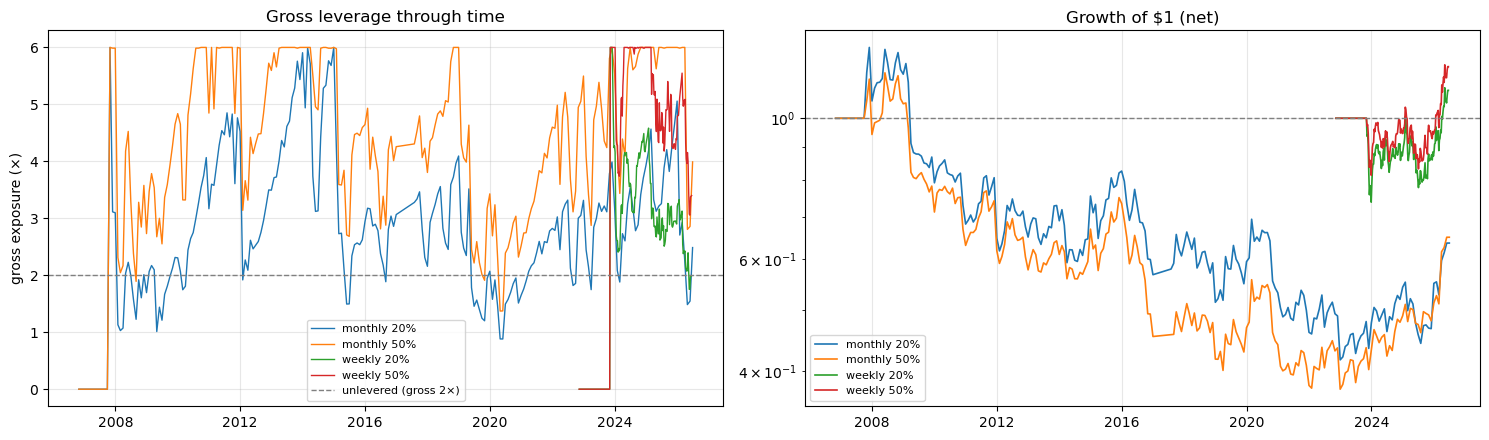

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm, res in results.items():
    ax[0].plot(res.leverage.index, res.leverage.values, label=nm, lw=1.0)
    eq = res.equity("net"); ax[1].plot(eq.index, eq.values, label=nm, lw=1.2)
ax[0].axhline(2.0, ls="--", color="grey", lw=1, label="unlevered (gross 2×)")
ax[0].set_title("Gross leverage through time"); ax[0].set_ylabel("gross exposure (×)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(1.0, ls="--", color="grey", lw=1); ax[1].set_yscale("log")
ax[1].set_title("Growth of $1 (net)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
pd.DataFrame({nm: res.leverage for nm, res in results.items()}).to_csv(f"{RES}/figure_data/leverage.csv")
pd.DataFrame({nm: res.equity("net") for nm, res in results.items()}).to_csv(f"{RES}/figure_data/growth.csv")
fig.savefig(f"{RES}/figures/leverage_and_growth.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 4. Dashboard — monthly 20%

2×3 dashboard for the monthly 20% book (benchmark panel = long-only index, reference
only — this is market-neutral). The drawdown panel exposes the **2009 momentum crash**.

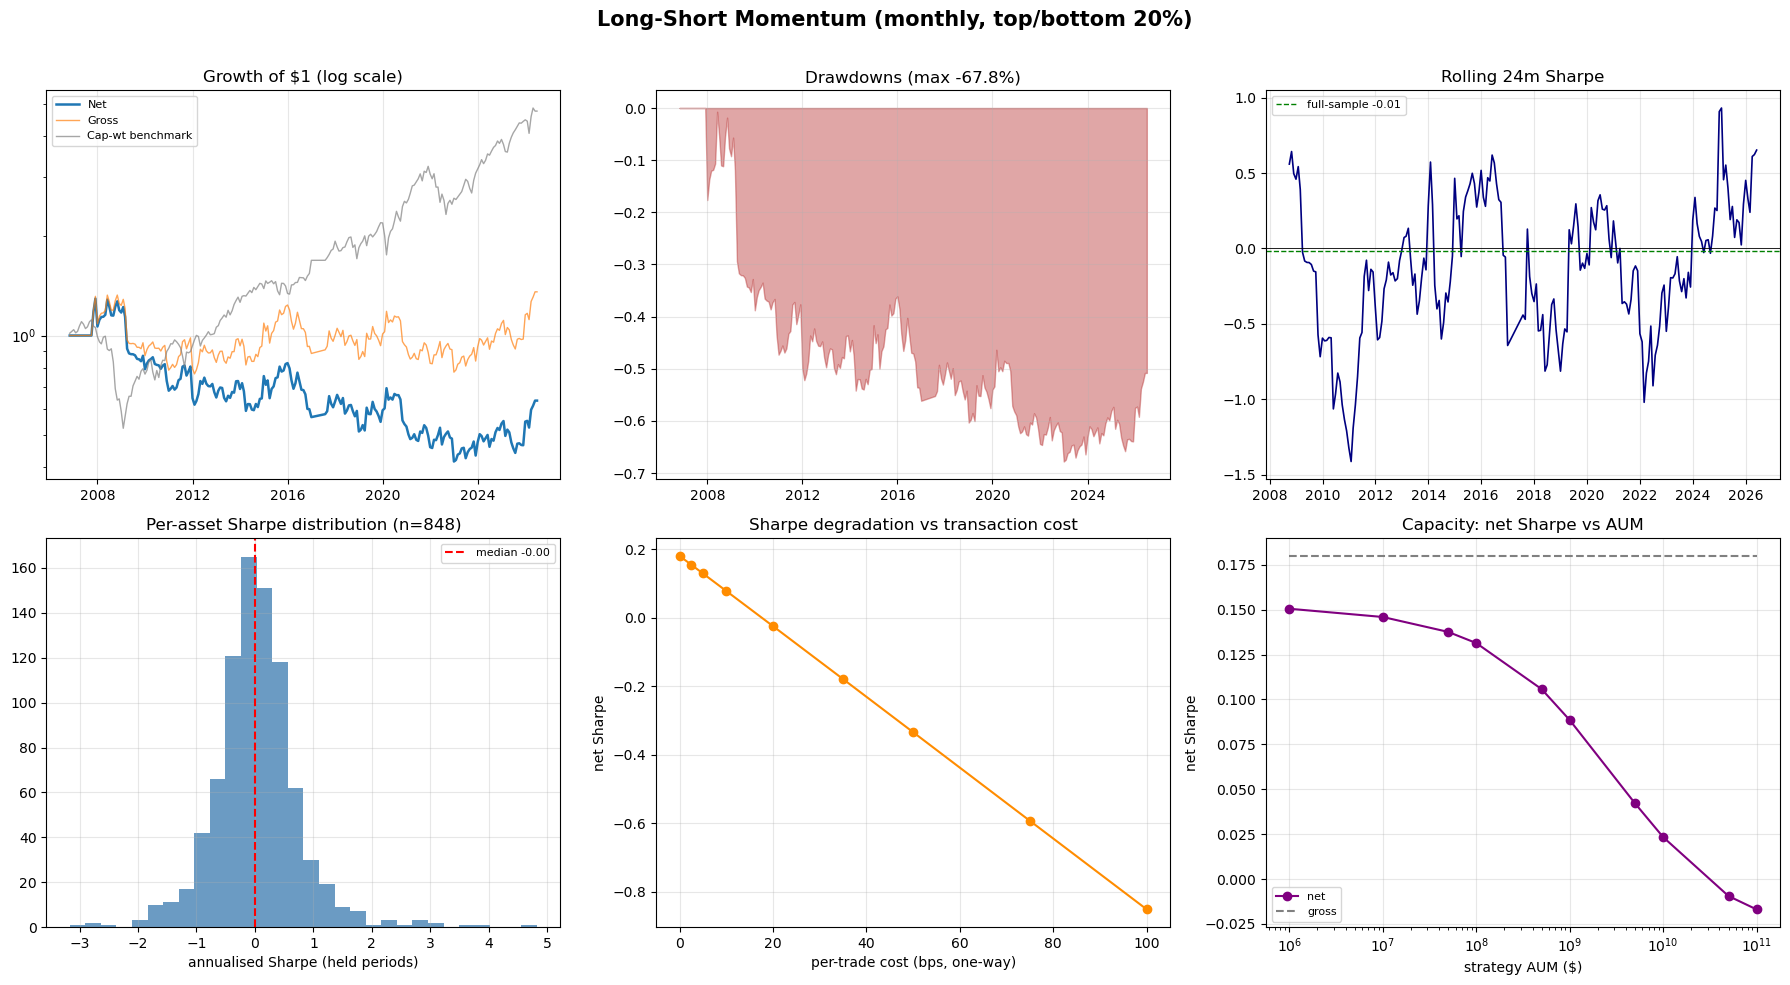

In [5]:
sig_m = ms.build_signal(md_m, variants["monthly 20%"][2])
ms.plot_strategy_dashboard(results["monthly 20%"], md_m, sig_m,
    "Long-Short Momentum (monthly, top/bottom 20%)",
    fig_path=f"{RES}/figures/ls_monthly_dashboard.png", data_dir=f"{RES}/figure_data",
    slug="ls_monthly"); plt.show()

## 5. Conclusions

* **Leverage scales with width.** Dollar-neutral (net ≈ 0). The **wider 50% book has
  the lowest spread vol** → it needs the **most** leverage (often pinned at the 6× cap)
  and may not even reach 20% vol; the **20% book** runs ~2.4–2.8× gross. Concentrating
  raises spread vol and lowers the leverage needed.
* **Performance.** The short leg does **not** earn its keep in S&P large-caps at either
  width: **monthly** long-short is roughly **flat-to-negative** with a **catastrophic
  ~−60–70% drawdown** from the 2009 momentum crash, plus **~4–6%/yr cost drag** (both
  legs, levered) before borrow fees. **Weekly** (short 2022-11+ sample) is mildly
  positive but weak.
* **Bottom line.** Long-short momentum here is a **levered, crash-prone, ~zero-edge**
  book regardless of width; the long-only / trend-filtered books remain the better
  expression of the signal.